**Install Libraries**

In [17]:
!pip install transformers datasets torch scikit-learn pandas matplotlib seaborn -q

**Import Libraries**

In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer

**Load Dataset**

In [8]:
dataset = load_dataset("imdb")

# Reduce dataset size for fast training
train_data = dataset["train"].shuffle(seed=42).select(range(2000))
test_data = dataset["test"].shuffle(seed=42).select(range(1000))

dataset = {"train": train_data, "test": test_data}

print("Train size:", len(dataset["train"]))
print("Test size:", len(dataset["test"]))

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train size: 2000
Test size: 1000


**Tokenization**

In [9]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

train_dataset = dataset["train"].map(tokenize_function, batched=True)
test_dataset = dataset["test"].map(tokenize_function, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

train_dataset = train_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
test_dataset.set_format("torch")

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

**Load BERT Model**

In [10]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Metrics Function**

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

**Experiment 1: Frozen BERT**

In [15]:
for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir="./results_frozen",
    # evaluation_strategy="epoch", # This argument is not recognized in the current transformers version.
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    save_strategy="no"
)

trainer_frozen = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Training Frozen BERT...")
trainer_frozen.train()

results_frozen = trainer_frozen.evaluate()
print("Frozen BERT Results:", results_frozen)

Training Frozen BERT...


Step,Training Loss


Frozen BERT Results: {'eval_loss': 0.6895795464515686, 'eval_accuracy': 0.546, 'eval_precision': 0.5602836879432624, 'eval_recall': 0.3237704918032787, 'eval_f1': 0.4103896103896104, 'eval_runtime': 32.8031, 'eval_samples_per_second': 30.485, 'eval_steps_per_second': 3.811, 'epoch': 1.0}


**Experiment 2: Fine-Tune Last 2 Layers**

In [12]:
model2 = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

for param in model2.bert.parameters():
    param.requires_grad = False

for layer in model2.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

training_args2 = TrainingArguments(
    output_dir="./results_partial",
    # evaluation_strategy="epoch", # This argument is not recognized in the current transformers version.
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    save_strategy="no"
)

trainer_partial = Trainer(
    model=model2,
    args=training_args2,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Training Partial Fine-Tuning...")
trainer_partial.train()

results_partial = trainer_partial.evaluate()
print("Partial Fine-Tuning Results:", results_partial)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Partial Fine-Tuning...


Step,Training Loss


Partial Fine-Tuning Results: {'eval_loss': 0.4363688826560974, 'eval_accuracy': 0.818, 'eval_precision': 0.7931034482758621, 'eval_recall': 0.8483606557377049, 'eval_f1': 0.8198019801980198, 'eval_runtime': 32.2133, 'eval_samples_per_second': 31.043, 'eval_steps_per_second': 3.88, 'epoch': 1.0}


**Classification Report and Confusion Matrix**


Classification Report:
              precision    recall  f1-score   support

    Negative       0.85      0.79      0.82       512
    Positive       0.79      0.85      0.82       488

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



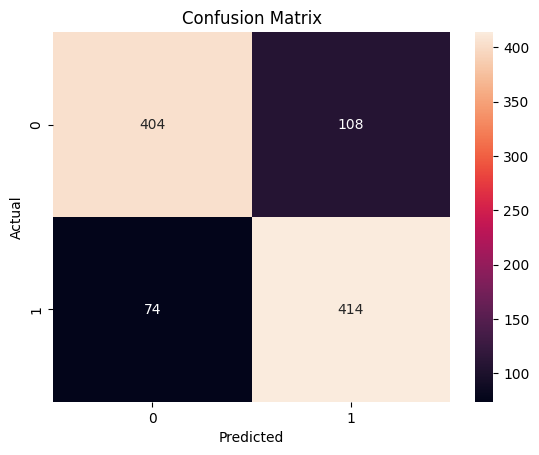

In [13]:
predictions = trainer_partial.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = test_dataset["labels"]

print("\nClassification Report:")
print(classification_report(labels, preds, target_names=["Negative", "Positive"]))

cm = confusion_matrix(labels, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Final Results Comparison**

In [16]:
print("\n")
print("FINAL RESULTS COMPARISON")
print("")

print("Frozen BERT Accuracy:", results_frozen["eval_accuracy"])
print("Partial Fine-Tuning Accuracy:", results_partial["eval_accuracy"])



FINAL RESULTS COMPARISON

Frozen BERT Accuracy: 0.546
Partial Fine-Tuning Accuracy: 0.818


**Expected Pipeline Flow**

Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison

**Conclusion**

In this project, I fine-tuned a pre-trained BERT model on the IMDB dataset for sentiment analysis. I performed experiments by freezing BERT layers and fine-tuning the last two layers and compared their performance. The fine-tuned model performed better than the frozen model. The model was evaluated using accuracy, precision, recall, F1 score, and confusion matrix. This project helped me understand BERT fine-tuning and transformer-based text classification.